# Simulate any BNGL model

A template: choose the model, the simulation time, and the parameter and observable to explore in the first cell, then run the notebook.

Simulations use [bngsim](https://bngsim.readthedocs.io), which loads BioNetGen models directly and runs ODE and stochastic (SSA) simulations in-process. `bngsim.Model.from_bngl` generates the reaction network with BioNetGen and loads it; the `simulate` actions at the end of the `.bngl` file are not run.

Two things to remember:
- Parameters are changed on the **model** (`model.set_param`), and simulations are run by a **simulator** (`sim.run`).
- A run starts from the model's *current* state. Call `model.reset()` before each run to start from the initial conditions (this also applies new initial-condition parameters such as `L0`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bngsim

# Choose a model and what to explore
infile = "../models/mapk3_inh.bngl"
t_end = 5000
pname, o = 'kin_inh_factor', 'ppERK'   # parameter to vary, observable to plot

#infile = "../models/lr_init.bngl"
#t_end = 200
#pname, o = 'L0', 'LR'

model = bngsim.Model.from_bngl(infile)
sim = bngsim.Simulator(model, method="ode")
defaults = {p: model.get_param(p) for p in model.primary_param_names}
print("parameters: ", model.primary_param_names)
print("observables:", model.observable_names)

parameters:  ['k1', 'k2', 'kkin', 'kptp', 'kin_inh_factor']
observables: ['RasRaf', 'pRaf', 'ppMEK', 'ppERK']


## Run a single simulation and plot the results

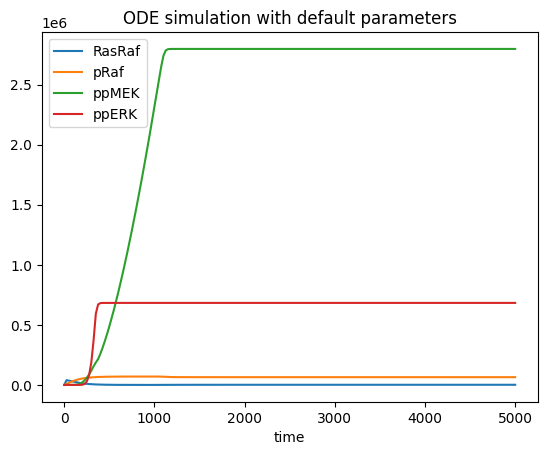

In [2]:
onames = model.observable_names
model.reset()
res1 = sim.run(t_span=(0, t_end), n_points=201)

for ob in onames:
    plt.plot(res1.time, res1.observables[ob], label=ob)
plt.title("ODE simulation with default parameters")
plt.xlabel("time")
_ = plt.legend()

## Compare simulations with different parameter values

Values range from 1/100 to 100 times the default.

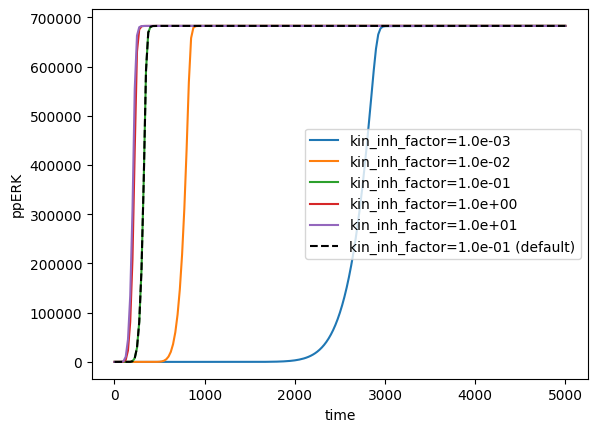

In [3]:
for k in defaults[pname] * np.logspace(-2, 2, 5):
    model.set_param(pname, k)
    model.reset()
    res2 = sim.run(t_span=(0, t_end), n_points=201)
    plt.plot(res2.time, res2.observables[o], label=f'{pname}={k:0.1e}')
plt.plot(res1.time, res1.observables[o], 'k--', label=f'{pname}={defaults[pname]:0.1e} (default)')
model.set_param(pname, defaults[pname])
plt.xlabel("time")
plt.ylabel(o)
_ = plt.legend(loc='best')

## Scan the parameter and plot the final value of the observable

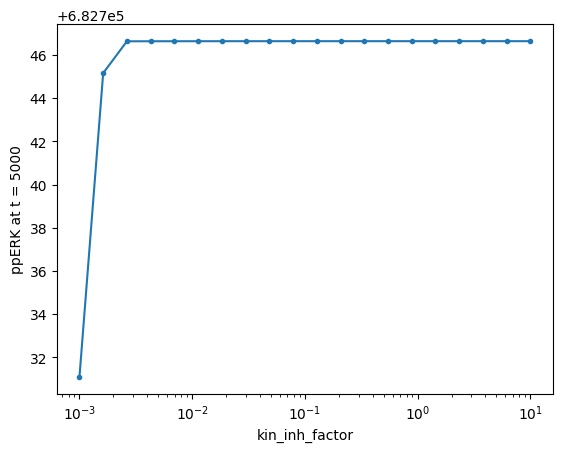

In [4]:
krange = defaults[pname] * np.logspace(-2, 2, 20)
out = []
for k in krange:
    model.set_param(pname, k)
    # Must reset AFTER changing a parameter that sets an initial condition.
    model.reset()
    res2 = sim.run(t_span=(0, t_end), n_points=201)
    out.append(res2.observables[o][-1])
model.set_param(pname, defaults[pname])

plt.semilogx(krange, out, '.-')
plt.xlabel(pname)
_ = plt.ylabel(f'{o} at t = {t_end}')